#Import data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-02-14/age_gaps.csv"
age_gaps = pd.read_csv(url)

age_gaps.columns = age_gaps.columns.str.lower()

# Parse dates
date_cols = [c for c in age_gaps.columns if "birthdate" in c]
for c in date_cols:
    age_gaps[c] = pd.to_datetime(age_gaps[c], errors="coerce")

age_gaps.info()
age_gaps.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   movie_name          1155 non-null   object        
 1   release_year        1155 non-null   int64         
 2   director            1155 non-null   object        
 3   age_difference      1155 non-null   int64         
 4   couple_number       1155 non-null   int64         
 5   actor_1_name        1155 non-null   object        
 6   actor_2_name        1155 non-null   object        
 7   character_1_gender  1155 non-null   object        
 8   character_2_gender  1155 non-null   object        
 9   actor_1_birthdate   1155 non-null   datetime64[ns]
 10  actor_2_birthdate   1155 non-null   datetime64[ns]
 11  actor_1_age         1155 non-null   int64         
 12  actor_2_age         1155 non-null   int64         
dtypes: datetime64[ns](2), int64(5), object(6)
memory

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


#Data Preprocessing

Check missing value

In [2]:
age_gaps.isna().sum()

,0
movie_name,0
release_year,0
director,0
age_difference,0
couple_number,0
actor_1_name,0
actor_2_name,0
character_1_gender,0
character_2_gender,0
actor_1_birthdate,0


Drop useless column

In [3]:
age_gaps_copy = age_gaps.copy()
age_gaps_copy=age_gaps_copy.drop(columns=['actor_1_birthdate', 'actor_2_birthdate', 'couple_number'])

# Feature Engineering

Add new features

In [4]:
#Add new feature: younger_age
age_gaps_copy['younger_age'] = age_gaps_copy[['actor_1_age', 'actor_2_age']].min(axis=1)

#Add new feature: older_age
age_gaps_copy['order_age'] = age_gaps_copy[['actor_1_age', 'actor_2_age']].max(axis=1)

#Add new feature: mean_age_of_couple
age_gaps_copy['mean_age_of_couple'] = (age_gaps_copy['younger_age'] + age_gaps_copy['order_age'])/2

#Add new column named " relative_age_gap"
age_gaps_copy['relative_age_gap'] = age_gaps_copy['age_difference']/age_gaps_copy['younger_age']

#Add new feature: relationship_type
age_gaps_copy["relationship_type"] = np.where(
    age_gaps_copy["character_1_gender"] == age_gaps_copy["character_2_gender"],
    "Same-gender",
    "Heterosexual"
)

#Convert same-gender label into numeric
age_gaps_copy["same_gender_bin"] = (
    age_gaps_copy["relationship_type"] == "Same-gender"
).astype(int)

#Add new feature: who_is_older
age_gaps_copy["who_is_older"] = np.where(
    age_gaps_copy["relationship_type"] != "Heterosexual",
   "Same-gender",
    np.where(
        age_gaps_copy["actor_1_age"] > age_gaps_copy["actor_2_age"],
        age_gaps_copy["character_1_gender"],
        np.where(
            age_gaps_copy["actor_2_age"] > age_gaps_copy["actor_1_age"],
            age_gaps_copy["character_2_gender"],
            "same_age"
        )
    )
)

#Add new feature: by_decade
age_gaps_copy["by_decade"] = (age_gaps_copy["release_year"] // 10) * 10

In [5]:
age_gaps_copy.head()

,movie_name,release_year,director,age_difference,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_age,actor_2_age,younger_age,order_age,mean_age_of_couple,relative_age_gap,relationship_type,same_gender_bin,who_is_older,by_decade
0,Harold and Maude,1971,Hal Ashby,52,Ruth Gordon,Bud Cort,woman,man,75,23,23,75,49.0,2.260870,Heterosexual,0,woman,1970
1,Venus,2006,Roger Michell,50,Peter O'Toole,Jodie Whittaker,man,woman,74,24,24,74,49.0,2.083333,Heterosexual,0,man,2000
2,The Quiet American,2002,Phillip Noyce,49,Michael Caine,Do Thi Hai Yen,man,woman,69,20,20,69,44.5,2.450000,Heterosexual,0,man,2000
3,The Big Lebowski,1998,Joel Coen,45,David Huddleston,Tara Reid,man,woman,68,23,23,68,45.5,1.956522,Heterosexual,0,man,1990
4,Beginners,2010,Mike Mills,43,Christopher Plummer,Goran Visnjic,man,man,81,38,38,81,59.5,1.131579,Same-gender,1,Same-gender,2010


In [6]:
age_gaps_copy.columns

Index(['movie_name', 'release_year', 'director', 'age_difference',
       'actor_1_name', 'actor_2_name', 'character_1_gender',
       'character_2_gender', 'actor_1_age', 'actor_2_age', 'younger_age',
       'order_age', 'mean_age_of_couple', 'relative_age_gap',
       'relationship_type', 'same_gender_bin', 'who_is_older', 'by_decade'],
      dtype='object')

#Feature Normalization

In [7]:
# Build cluster matrix
cluster_df = age_gaps_copy[[
    "age_difference",
    "mean_age_of_couple",
    "relative_age_gap",
    "actor_1_age",
    "actor_2_age",
    "release_year"
]]
cluster_df

,age_difference,mean_age_of_couple,relative_age_gap,actor_1_age,actor_2_age,release_year
0,52,49.0,2.260870,75,23,1971
1,50,49.0,2.083333,74,24,2006
2,49,44.5,2.450000,69,20,2002
3,45,45.5,1.956522,68,23,1998
4,43,59.5,1.131579,81,38,2010
...,...,...,...,...,...,...
1150,0,23.0,0.000000,23,23,2013
1151,0,42.0,0.000000,42,42,2006
1152,0,30.0,0.000000,30,30,2019
1153,0,21.0,0.000000,21,21,2007


Standardization(StandardScaler)

In [8]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
# Normalize df
df_normalized = pd.DataFrame(sc.fit_transform(cluster_df), columns=cluster_df.columns)

df_normalized

,age_difference,mean_age_of_couple,relative_age_gap,actor_1_age,actor_2_age,release_year
0,4.887011,1.693628,5.471972,3.298045,-0.962437,-1.821604
1,4.651921,1.693628,4.956601,3.202072,-0.828974,0.317926
2,4.534377,1.132271,6.020999,2.722210,-1.362826,0.073408
3,4.064198,1.257017,4.588479,2.626238,-0.962437,-0.171109
4,3.829108,3.003460,2.193749,3.873879,1.039510,0.562444
...,...,...,...,...,...,...
1150,-1.225315,-1.549765,-1.091117,-1.692522,-0.962437,0.745832
1151,-1.225315,0.820407,-1.091117,0.130955,1.573363,0.317926
1152,-1.225315,-0.676544,-1.091117,-1.020715,-0.028195,1.112609
1153,-1.225315,-1.799257,-1.091117,-1.884466,-1.229363,0.379055


# PCA

In [9]:
!pip install psynlig -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.7/458.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.8 MB/s eta 0:00:00


In [10]:
df_numeric = age_gaps_copy[[
    "relative_age_gap",
    "mean_age_of_couple",
    "same_gender_bin"
]]

In [11]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
df_numeric_normalized = pd.DataFrame(
    sc.fit_transform(df_numeric),
    columns=df_numeric.columns
)

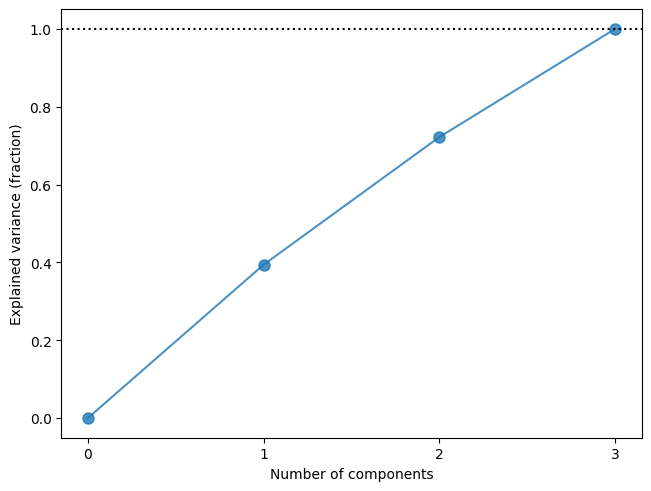

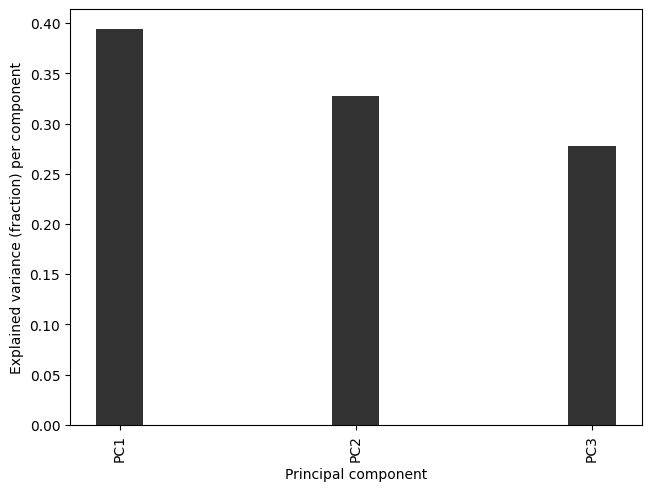

In [12]:
# Perform PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(df_numeric_normalized)

from matplotlib import pyplot as plt
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)

_, ax = pca_explained_variance(pca,  marker='o', markersize=8, alpha=0.8)

plt.show()

pca_explained_variance_bar(
    pca,
    width=0.2,
    alpha=0.8,
    color='black',
)

plt.show()

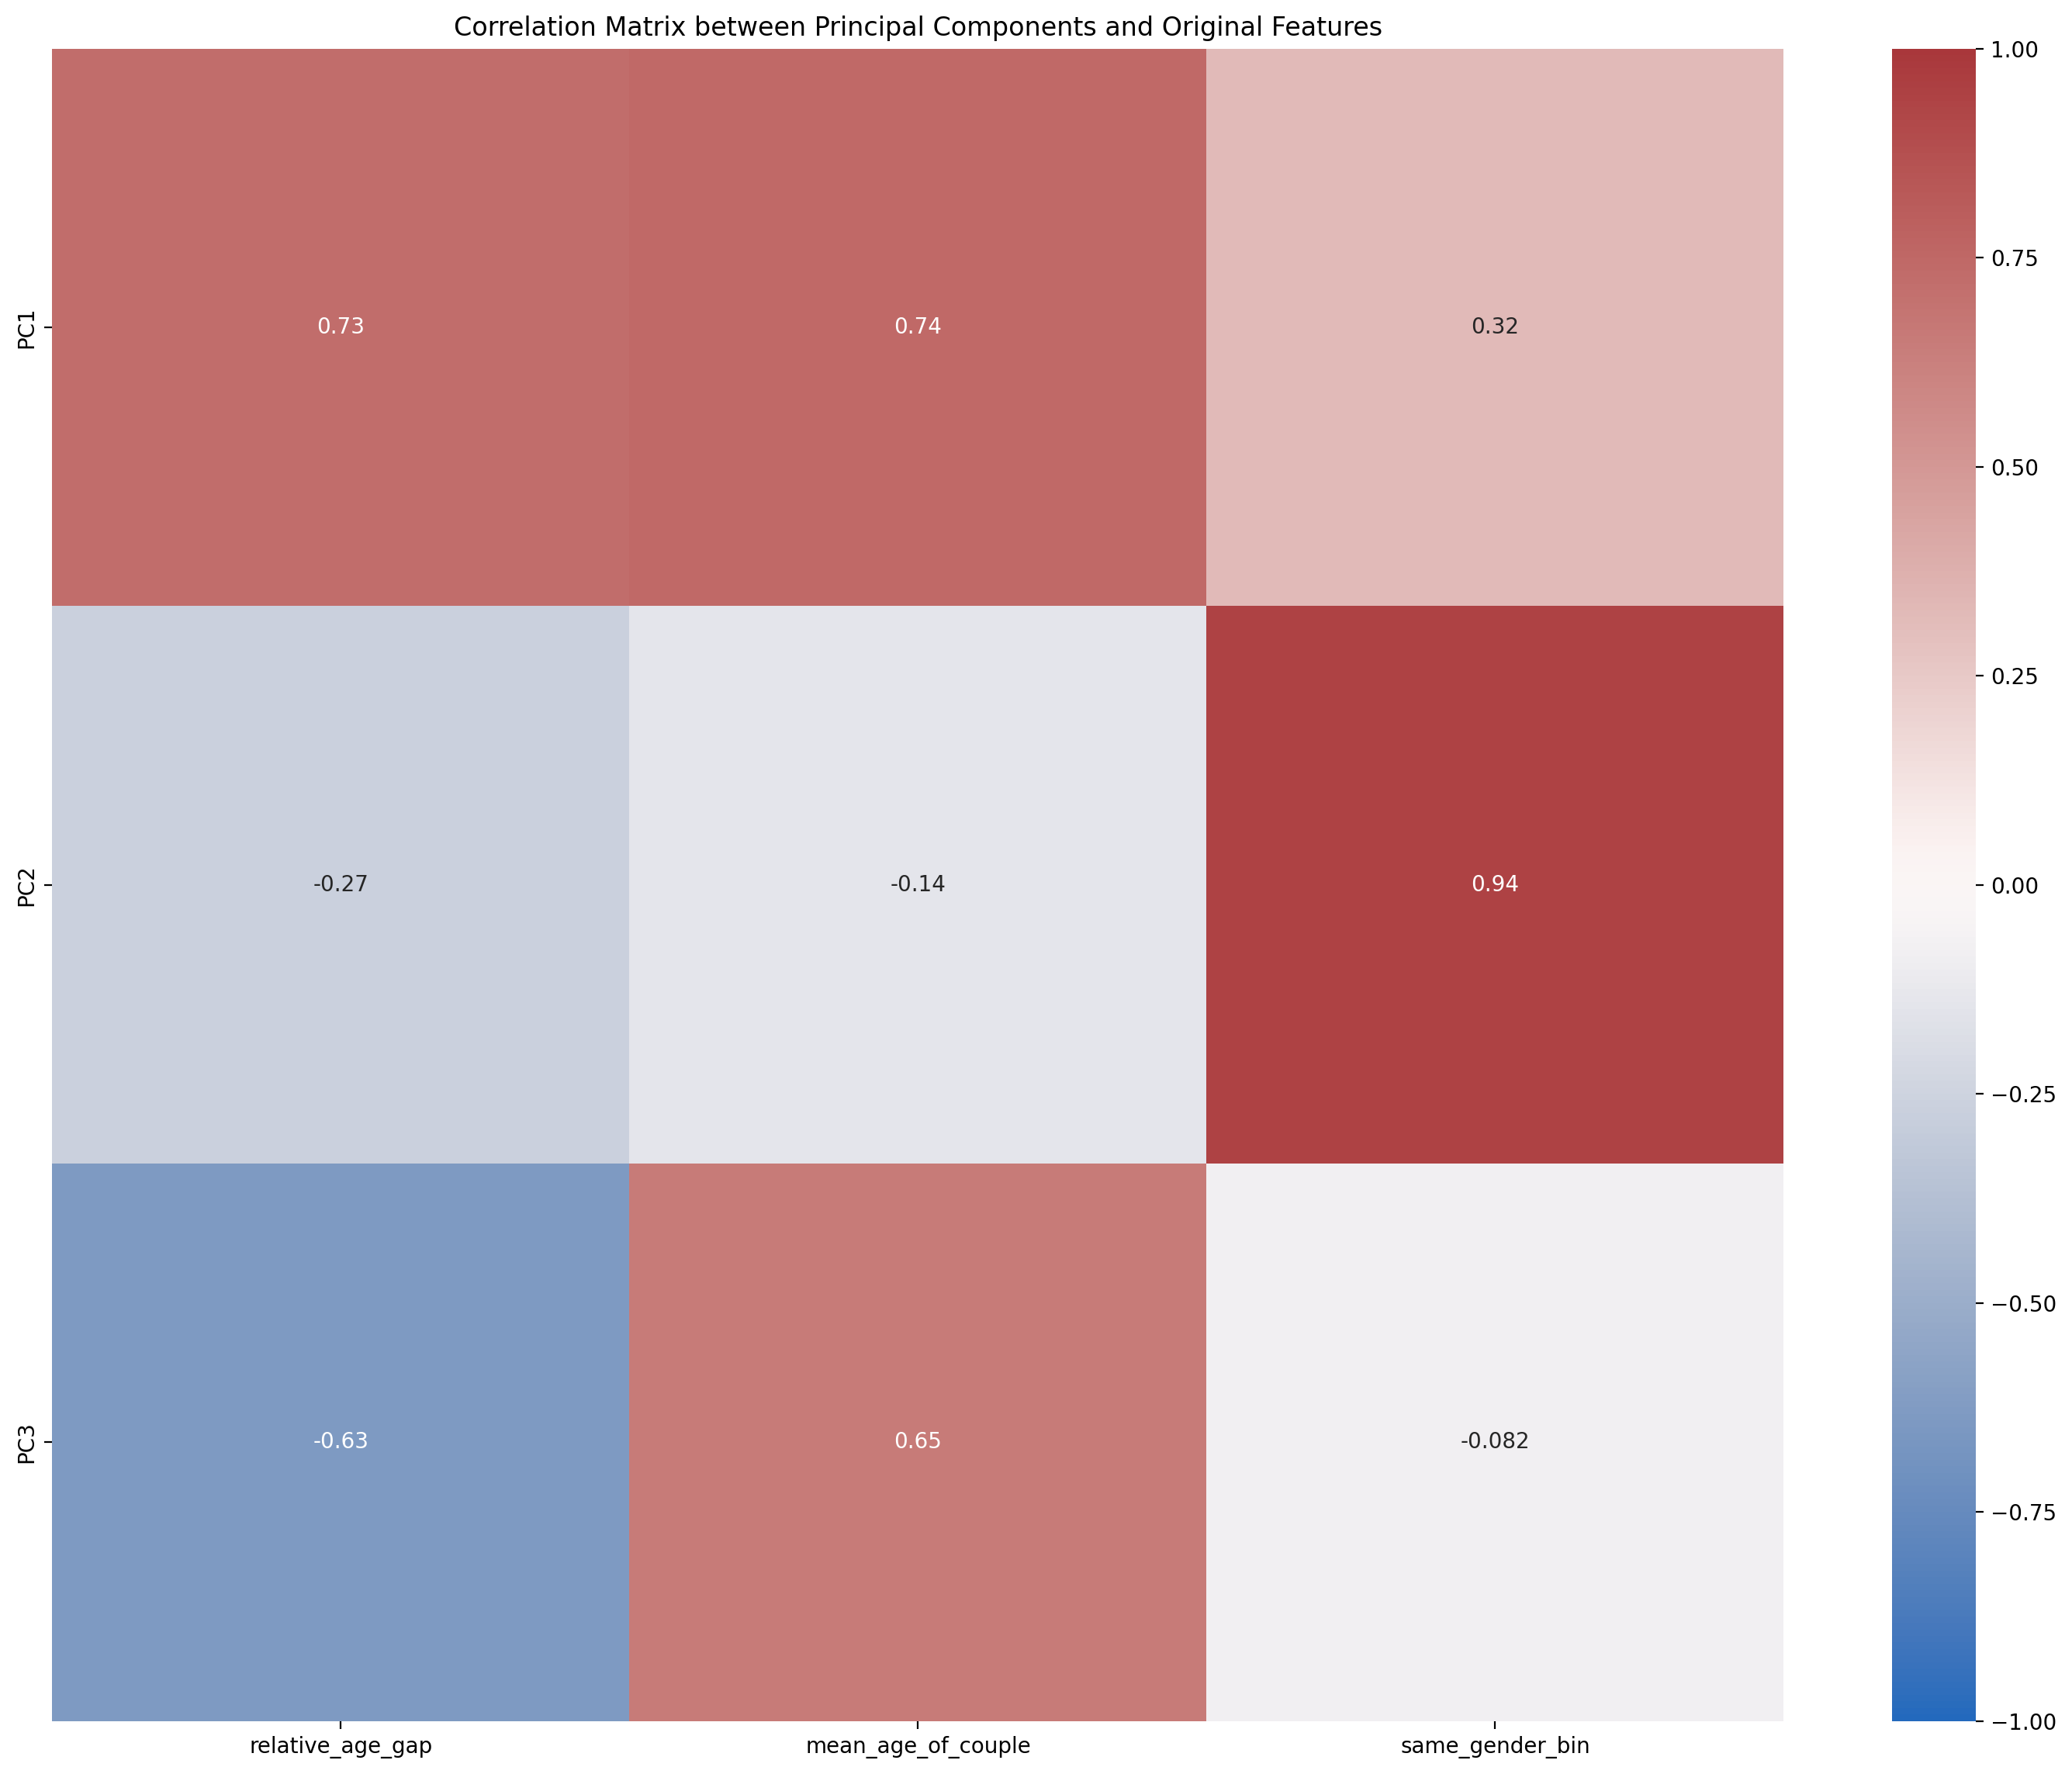

In [13]:
import seaborn as sns
# Data represented in terms of PCs
transformed_data = pd.DataFrame(pca.transform(df_numeric_normalized), columns = ['PC' + str(i+1) for i in range(len(pca.components_))])

# Concatenate the PCs and the normalized original features
combined_df = pd.concat([transformed_data, df_numeric_normalized.reset_index(drop=True)], axis=1)

# Calculate the correlation matrix
correlation_pcs_original = combined_df.corr().loc[transformed_data.columns, df_numeric_normalized.columns]

plt.figure(figsize=(18, 14), dpi=200)
sns.heatmap(correlation_pcs_original, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix between Principal Components and Original Features')
plt.show()

([<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>],
 [<Axes: title={'center': 'Loading coefficients for PC1'}, xlabel='Variables', ylabel='Coefficient'>,
  <Axes: title={'center': 'Loading coefficients for PC2'}, xlabel='Variables', ylabel='Coefficient'>])

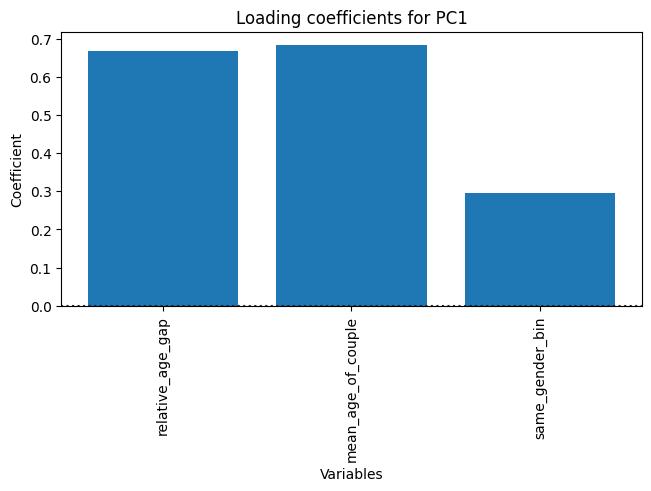

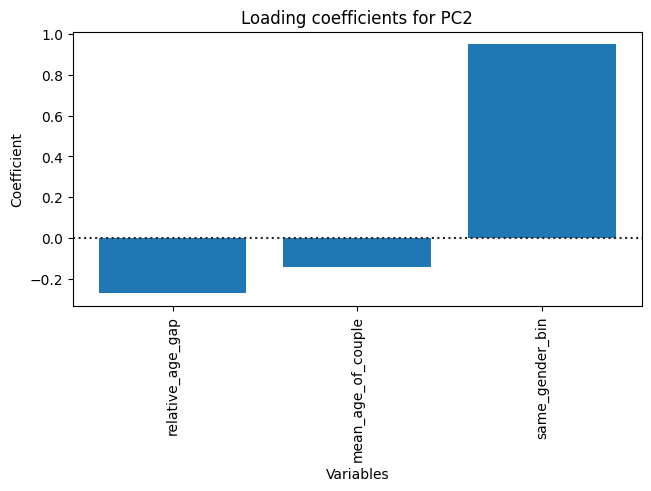

In [14]:
from psynlig import pca_1d_loadings

pca_1d_loadings(
    pca,
    df_numeric_normalized.columns,
    select_components={1, 2},
    plot_type="bar",
)

#Findings & Interpretations

In [15]:
# Add principal component scores to the dataset
PC_scores = pd.DataFrame(
    pca.transform(df_numeric_normalized),
    columns=["PC1","PC2","PC3"]
)

age_gaps_copy = age_gaps_copy.reset_index(drop=True)
age_gaps_copy = pd.concat([age_gaps_copy, PC_scores], axis=1)

In [16]:
# Calculate decade-level average PC scores
era_means = age_gaps_copy.groupby("by_decade")[["PC1","PC2","PC3"]].mean()
print(era_means)

                PC1       PC2       PC3
by_decade                              
1930      -0.299461 -0.110919 -0.569986
1940       0.964599 -0.542923 -0.997544
1950       0.843360 -0.463917 -0.558927
1960      -0.281905 -0.080382 -0.189263
1970       0.517042 -0.335802 -0.272958
1980       0.301757 -0.264325 -0.222342
1990      -0.149306 -0.085783 -0.170365
2000      -0.144376  0.060332 -0.001389
2010       0.058914  0.124132  0.265480
2020       0.744270  0.087741  0.530599


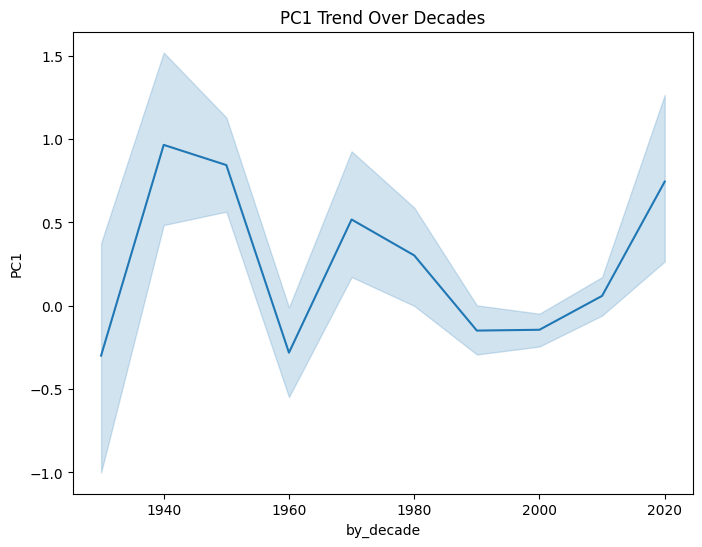

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.lineplot(data=age_gaps_copy, x="by_decade", y="PC1", estimator="mean")
plt.title("PC1 Trend Over Decades")
plt.show()

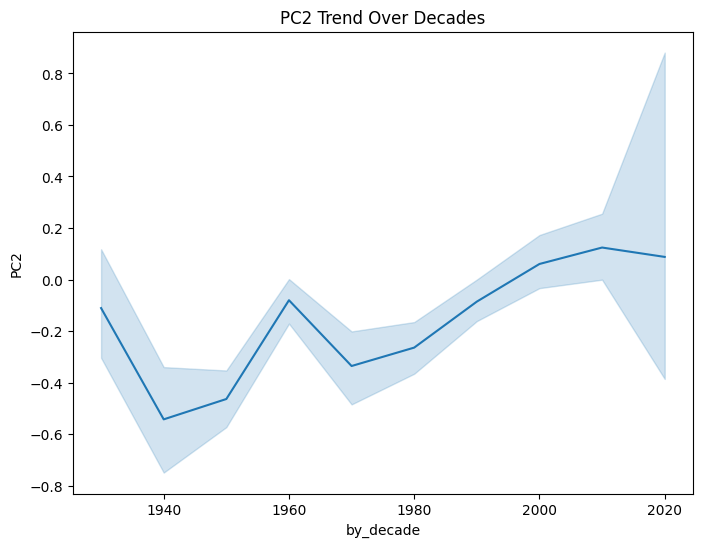

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.lineplot(data=age_gaps_copy, x="by_decade", y="PC2", estimator="mean")
plt.title("PC2 Trend Over Decades")
plt.show()

#K-means Cluster

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_normalized)

In [20]:
#Transfer PC to dataframe
import pandas as pd

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=age_gaps_copy.index
)

df_pca.head()

,PC1,PC2
0,6.760403,-5.082629
1,6.351431,-3.960135
2,5.987366,-5.085229
3,5.386076,-3.968176
4,6.532946,-0.526943


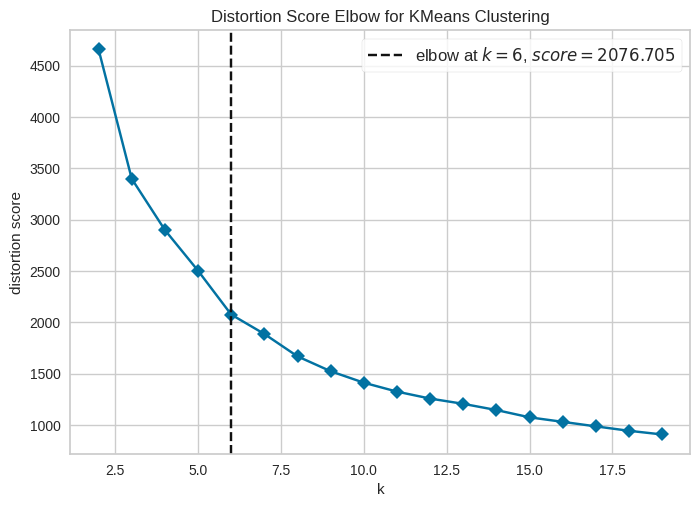

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [21]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 20), metric='distortion', timings=False, random_state=42  #metric='silhouette' metric='distortion'
)

visualizer.fit(df_normalized)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [22]:
n_clusters_kmeans = 3

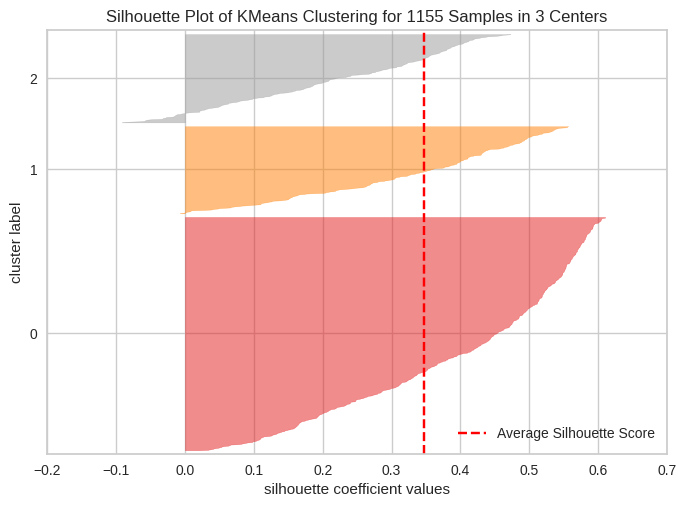

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1155 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [23]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(df_normalized)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [24]:
from sklearn.cluster import KMeans

# Initialize KMeans model with n_clusters and random_state=42
kmeans = KMeans(n_clusters=n_clusters_kmeans, random_state=42) # Trye different number of clusters

# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
df_normalized['cluster_labels'] = kmeans.fit_predict(df_normalized).astype(str)

# Display the value counts of the new cluster labels
print(df_normalized['cluster_labels'].value_counts())

cluster_labels
0    659
2    250
1    246
Name: count, dtype: int64


In [25]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(df_pca)

df_pca["cluster"] = labels
age_gaps_copy["cluster"] = labels

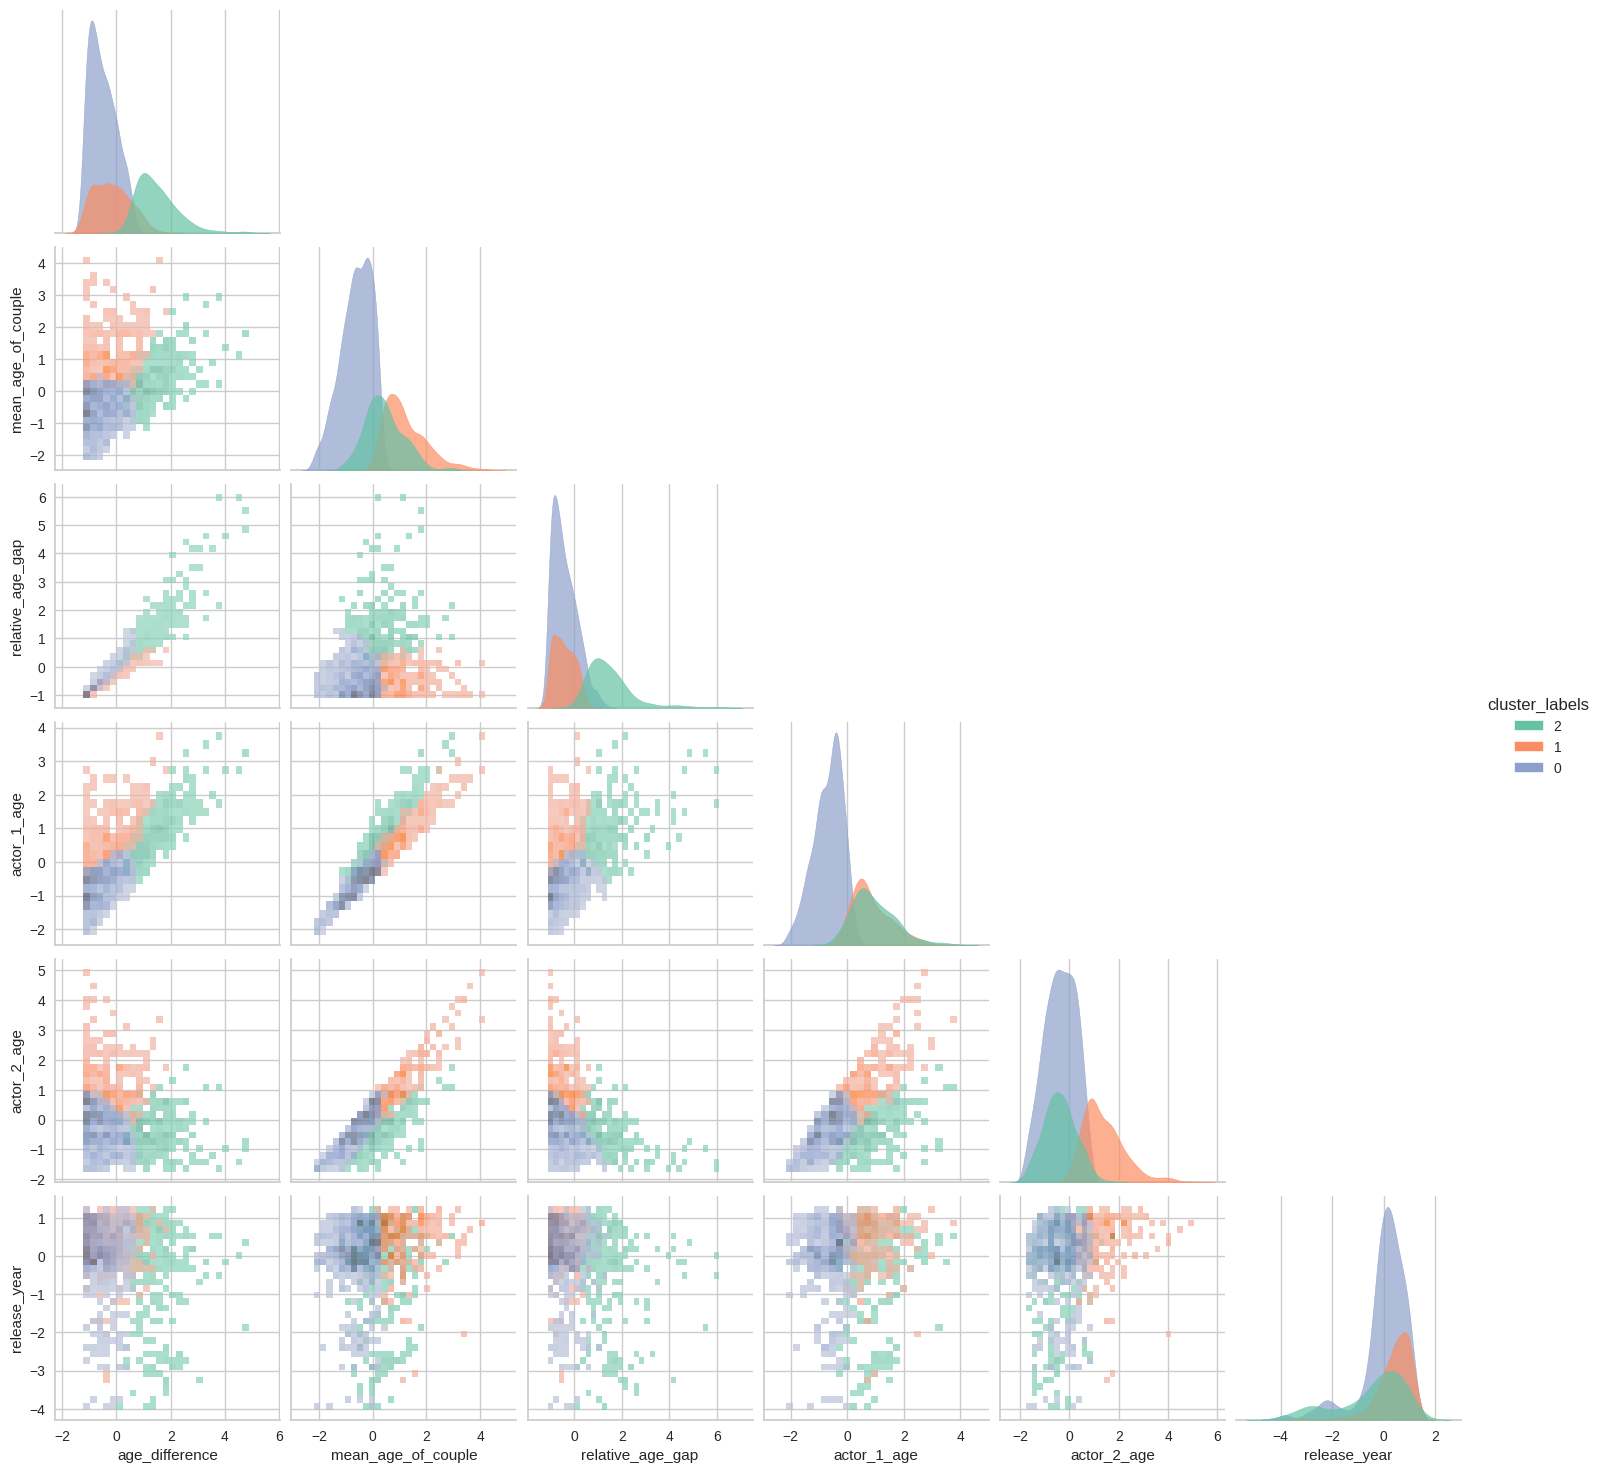

In [26]:
sns.pairplot(df_normalized, hue="cluster_labels", kind="hist", diag_kind="kde", corner=True, palette="Set2",
    plot_kws={'alpha': 0.7}, # Adjusts transparency of the scatter points (0.0 to 1.0)
    diag_kws={'alpha': 0.7}  # Adjusts transparency of the diagonal plots (histograms/KDEs)
    )